In [63]:
HOUSING_PATH = 'housing.csv'

In [64]:
import pandas as pd
import os
import numpy as np
def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

In [65]:
housing = pd.read_csv("housing.csv")
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [109]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 12655 to 19773
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16354 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   ocean_proximity     16512 non-null  object 
dtypes: float64(8), object(1)
memory usage: 1.3+ MB


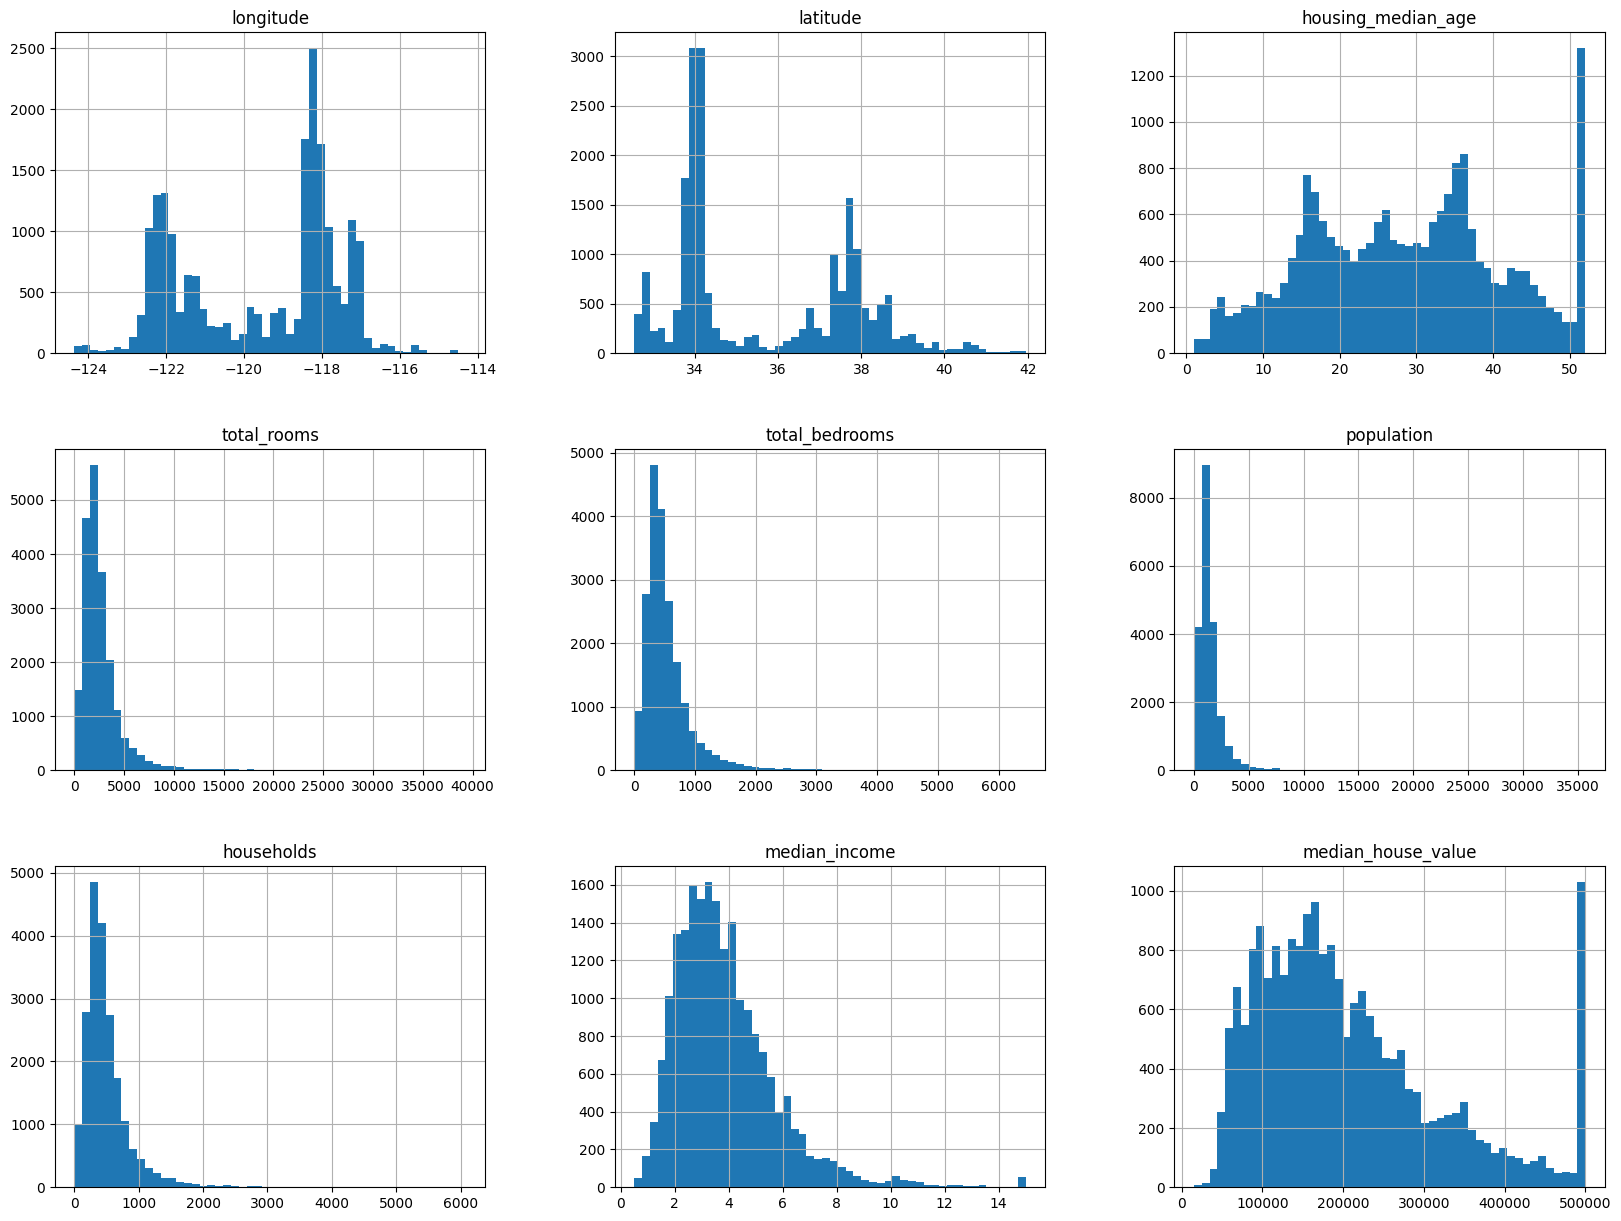

In [66]:
import matplotlib.pyplot as plt

housing.hist(bins=50, figsize=(20,15))
plt.show()

In [67]:
def splin_train_test(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

train_set, test_set = splin_train_test(housing, 0.2)
print(len(train_set), "train +", len(test_set), "test")

16512 train + 4128 test


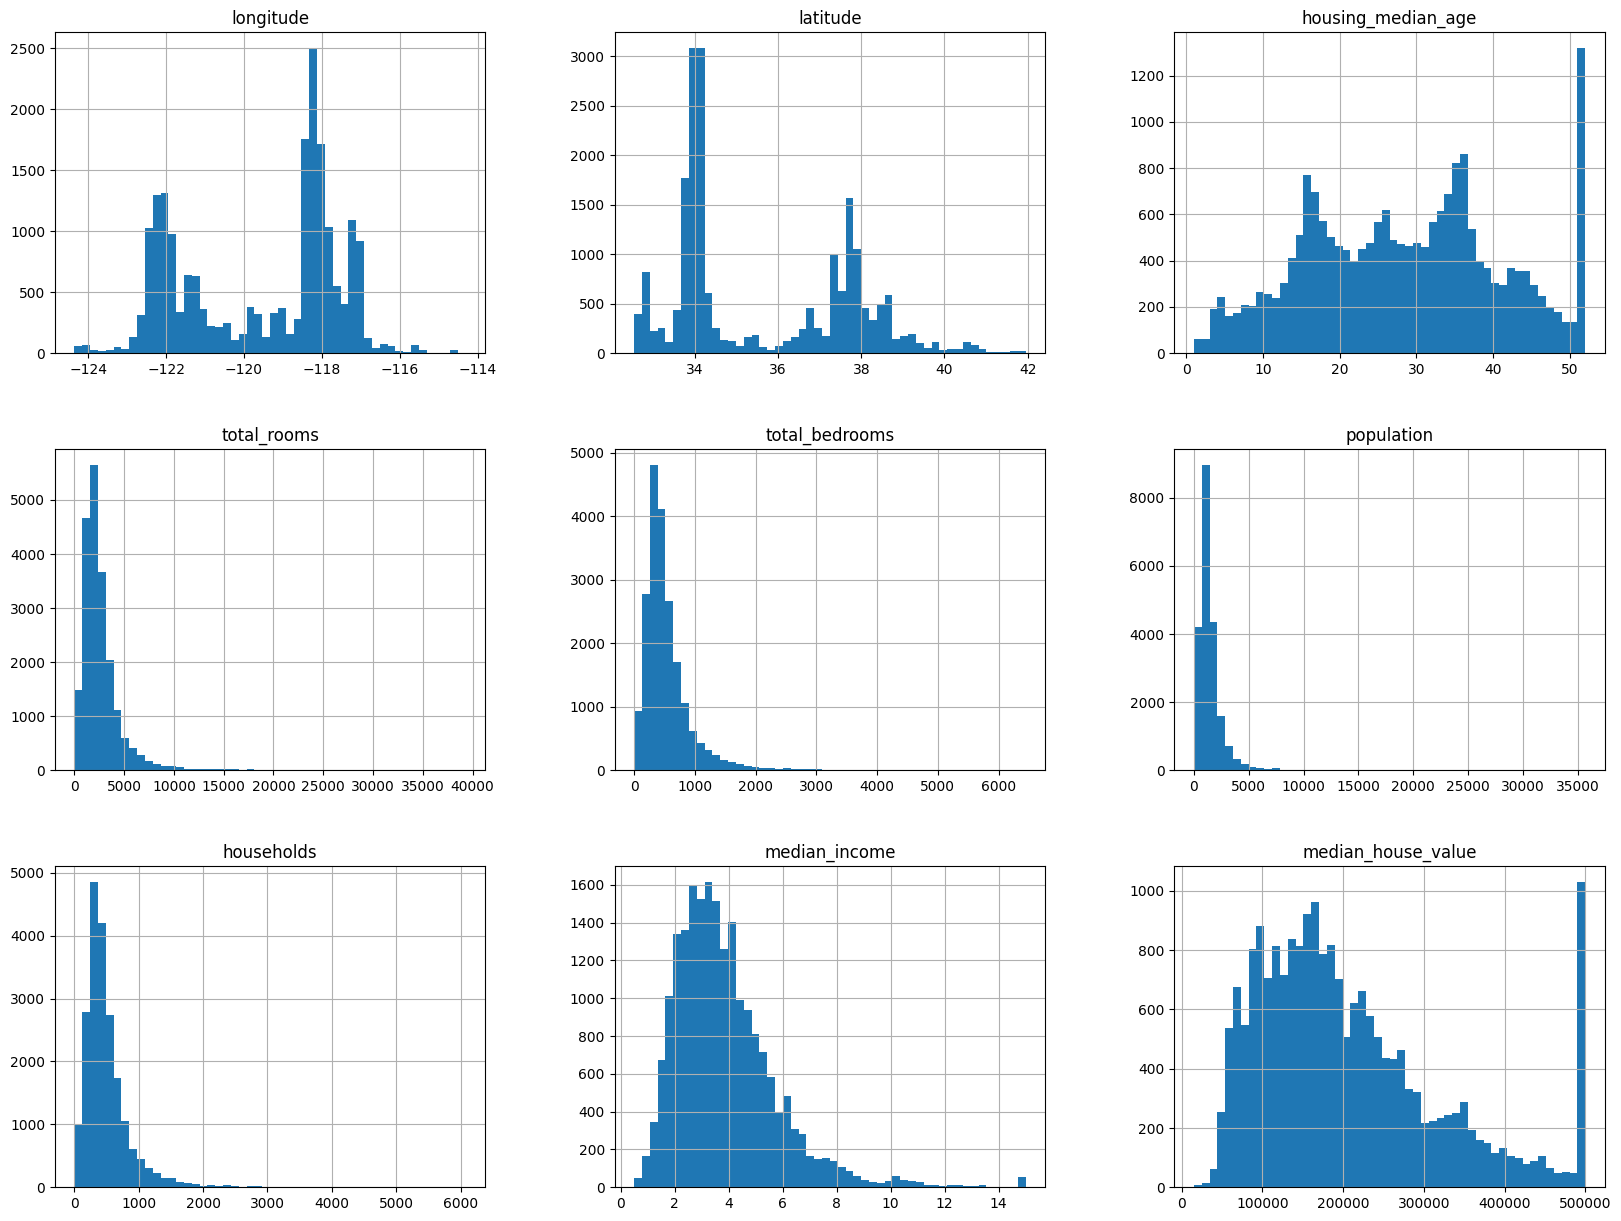

In [68]:
from sklearn.model_selection import train_test_split

housing = pd.read_csv("housing.csv")

housing.hist(bins=50, figsize=(20,15))
plt.show()

In [69]:
import hashlib

# Função simples de divisão aleatória em treino e teste
def split_train_test(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

# Aplica divisão aleatória
train_set, test_set = split_train_test(housing, 0.2)
print(len(train_set), "train +", len(test_set), "test")

# Função para verificar se uma amostra deve estar no conjunto de teste com base em hash
def test_set_check(identifier, test_ratio, hash):
    return hash(np.int64(identifier)).digest()[-1] < 256 * test_ratio 

# Função de divisão baseada em identificador (para resultados reprodutíveis)
def split_train_test_by_id(data, test_ratio, id_column, hash=hashlib.md5):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: test_set_check(id_, test_ratio, hash))
    return data.loc[~in_test_set], data.loc[in_test_set]

# Adiciona uma coluna 'index' como identificador único
housing_with_id = housing.reset_index()  # adiciona uma coluna 'index'

# Aplica divisão usando identificador
train_set_id, test_set_id = split_train_test_by_id(housing_with_id, 0.2, "index")
print(len(train_set_id), "train ID-based +", len(test_set_id), "test ID-based")

16512 train + 4128 test
16362 train ID-based + 4278 test ID-based


In [70]:
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)
print(len(train_set), "train +", len(test_set), "test")

16512 train + 4128 test


In [71]:
# Adiciona uma coluna de ID
housing_with_id = housing.reset_index()
housing_with_id["id"] = housing["longitude"] * 1000 + housing["latitude"]

# Split aleatório
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

# Cria a coluna de categoria de renda
housing["income_cat"] = np.ceil(housing["median_income"] / 1.5)
housing["income_cat"] = housing["income_cat"].where(housing["income_cat"] < 5, 5.0)
print(housing["income_cat"])

0        5.0
1        5.0
2        5.0
3        4.0
4        3.0
        ... 
20635    2.0
20636    2.0
20637    2.0
20638    2.0
20639    2.0
Name: income_cat, Length: 20640, dtype: float64


0        5.0
1        5.0
2        5.0
3        4.0
4        3.0
        ... 
20635    2.0
20636    2.0
20637    2.0
20638    2.0
20639    2.0
Name: income_cat, Length: 20640, dtype: float64


<Axes: xlabel='longitude', ylabel='latitude'>

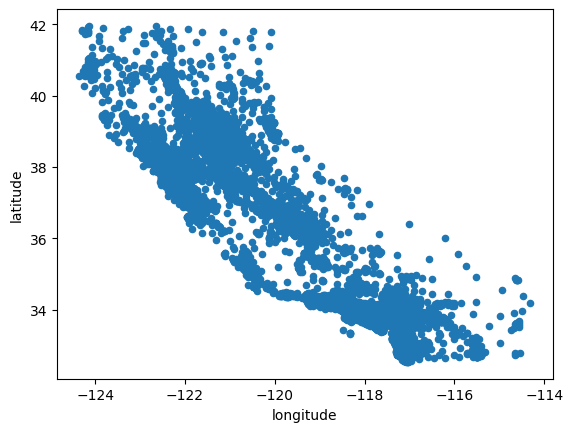

In [72]:
# Carrega o dataset
housing = pd.read_csv("housing.csv")

# Adiciona uma coluna de ID
housing_with_id = housing.reset_index()
housing_with_id["id"] = housing["longitude"] * 1000 + housing["latitude"]

# Split aleatório
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

# Cria a coluna de categoria de renda
housing["income_cat"] = np.ceil(housing["median_income"] / 1.5)
housing["income_cat"] = housing["income_cat"].where(housing["income_cat"] < 5, 5.0)
print(housing["income_cat"])
housing.plot(kind="scatter", x="longitude", y="latitude")

income_cat
3.0    7236
2.0    6581
4.0    3639
5.0    2362
1.0     822
Name: count, dtype: int64
0        5.0
1        5.0
2        5.0
3        4.0
4        3.0
        ... 
20635    2.0
20636    2.0
20637    2.0
20638    2.0
20639    2.0
Name: income_cat, Length: 20640, dtype: float64


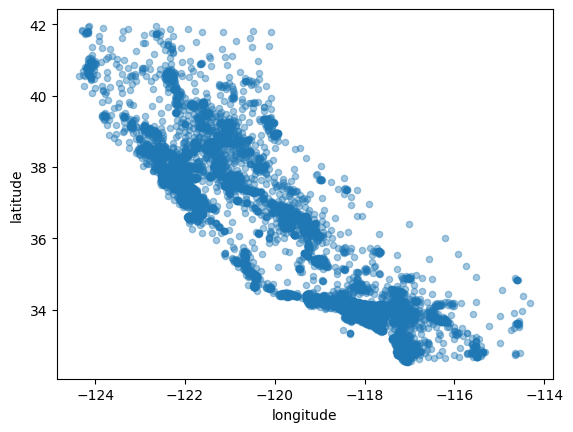

In [73]:
from sklearn.model_selection import StratifiedShuffleSplit

# Cria a coluna de categoria de renda
housing["income_cat"] = np.ceil(housing["median_income"] / 1.5)
housing["income_cat"] = housing["income_cat"].where(housing["income_cat"] < 5, 5.0)

# Verifica contagem de cada categoria
print(housing["income_cat"].value_counts())

# Remove categorias com poucos exemplos (opcional)
min_class_count = housing["income_cat"].value_counts().min()
if min_class_count < 2:
    housing = housing[housing["income_cat"].map(housing["income_cat"].value_counts()) > 1]

# Split estratificado
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.iloc[train_index].copy()
    strat_test_set = housing.iloc[test_index].copy()
# Remove income_cat
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

# Adiciona uma coluna de ID
housing_with_id = housing.reset_index()
housing_with_id["id"] = housing["longitude"] * 1000 + housing["latitude"]

# Exibe income_cat e plota
print(housing["income_cat"])
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4)
plt.show()


In [74]:
import hashlib
import pandas as pd 
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
import matplotlib.pyplot as plt

# Carrega o dataset
housing = pd.read_csv("housing.csv")
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)
print(corr_matrix)

                    longitude  latitude  housing_median_age  total_rooms  \
longitude            1.000000 -0.924664           -0.108197     0.044568   
latitude            -0.924664  1.000000            0.011173    -0.036100   
housing_median_age  -0.108197  0.011173            1.000000    -0.361262   
total_rooms          0.044568 -0.036100           -0.361262     1.000000   
total_bedrooms       0.069608 -0.066983           -0.320451     0.930380   
population           0.099773 -0.108785           -0.296244     0.857126   
households           0.055310 -0.071035           -0.302916     0.918484   
median_income       -0.015176 -0.079809           -0.119034     0.198050   
median_house_value  -0.045967 -0.144160            0.105623     0.134153   

                    total_bedrooms  population  households  median_income  \
longitude                 0.069608    0.099773    0.055310      -0.015176   
latitude                 -0.066983   -0.108785   -0.071035      -0.079809   
housing_

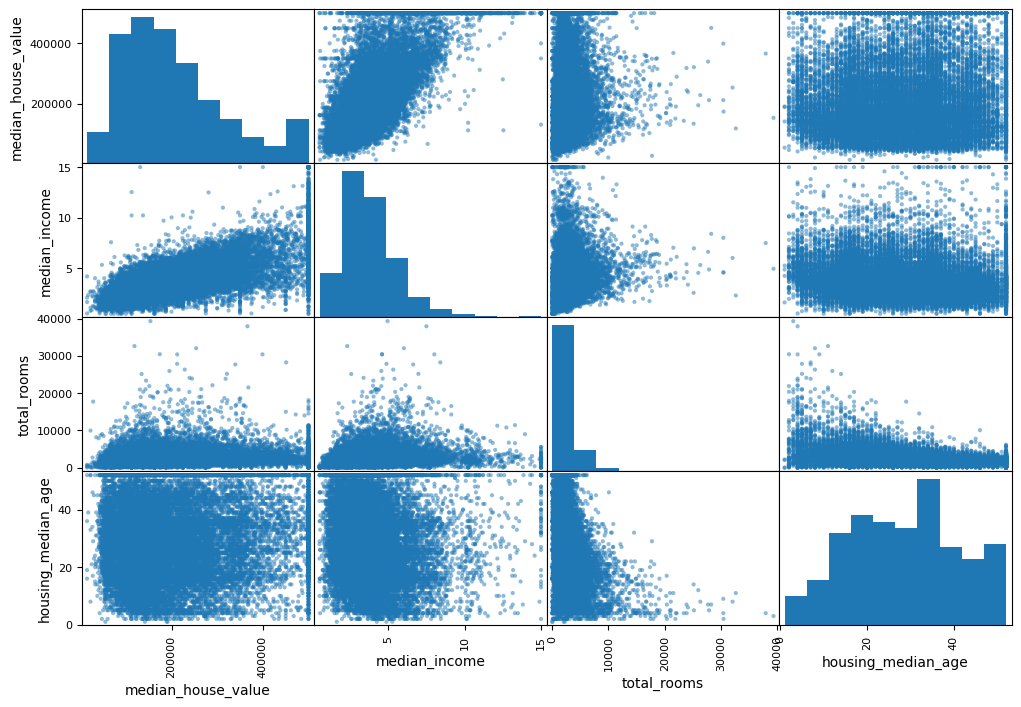

In [75]:
import pandas as pd 
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix  # <- Aqui está a correção

# Carrega o dataset
housing = pd.read_csv("housing.csv")

# Seleciona atributos e plota a matriz de dispersão
attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))
plt.show()

In [76]:
housing["incoming_cat"]  = pd.cut(housing["median_income"],
                                    bins=[0., 1.5, 3., 4.5, 6., np.inf],
                                    labels=[1, 2, 3, 4, 5])
print(housing["incoming_cat"].value_counts())

incoming_cat
3    7236
2    6581
4    3639
5    2362
1     822
Name: count, dtype: int64


In [77]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["incoming_cat"]):
    strat_train_set = housing.iloc[train_index].copy()
    strat_test_set = housing.iloc[test_index].copy()

strat_train_set["incoming_cat"].value_counts() / len(strat_train_set)

incoming_cat
3    0.350594
2    0.318859
4    0.176296
5    0.114462
1    0.039789
Name: count, dtype: float64

In [78]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("incoming_cat", axis=1, inplace=True)

<Axes: xlabel='longitude', ylabel='latitude'>

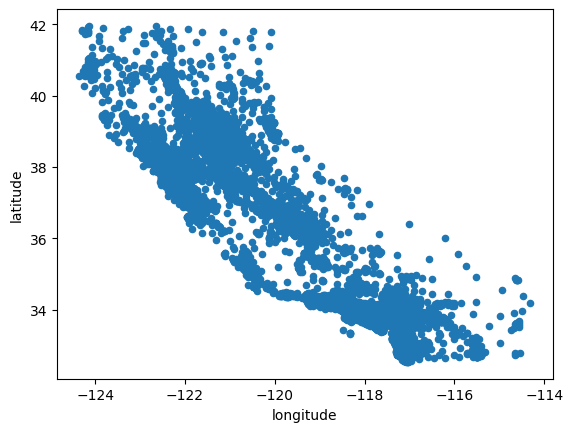

In [79]:
housing.plot(kind="scatter", x="longitude", y="latitude")

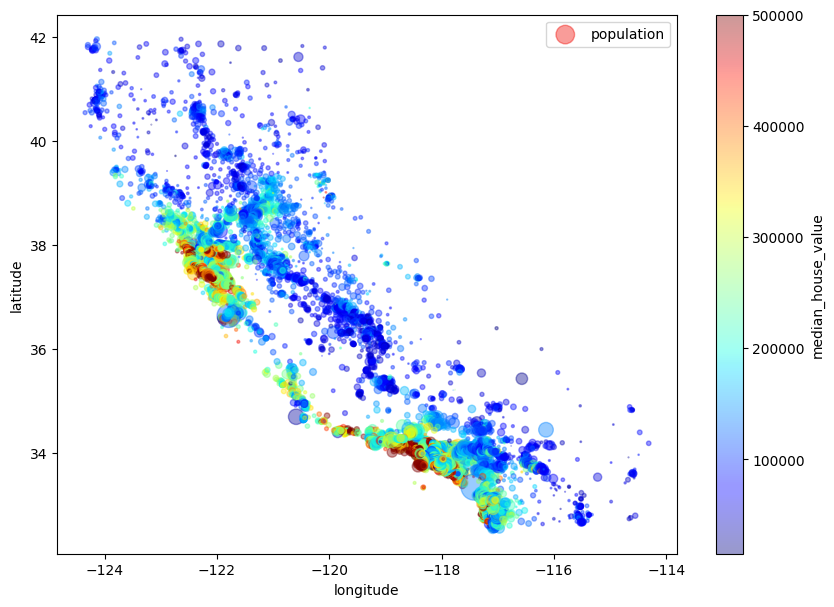

In [80]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
            s=housing["population"] / 100, label="population", figsize=(10, 7),
            c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
            )
plt.show()

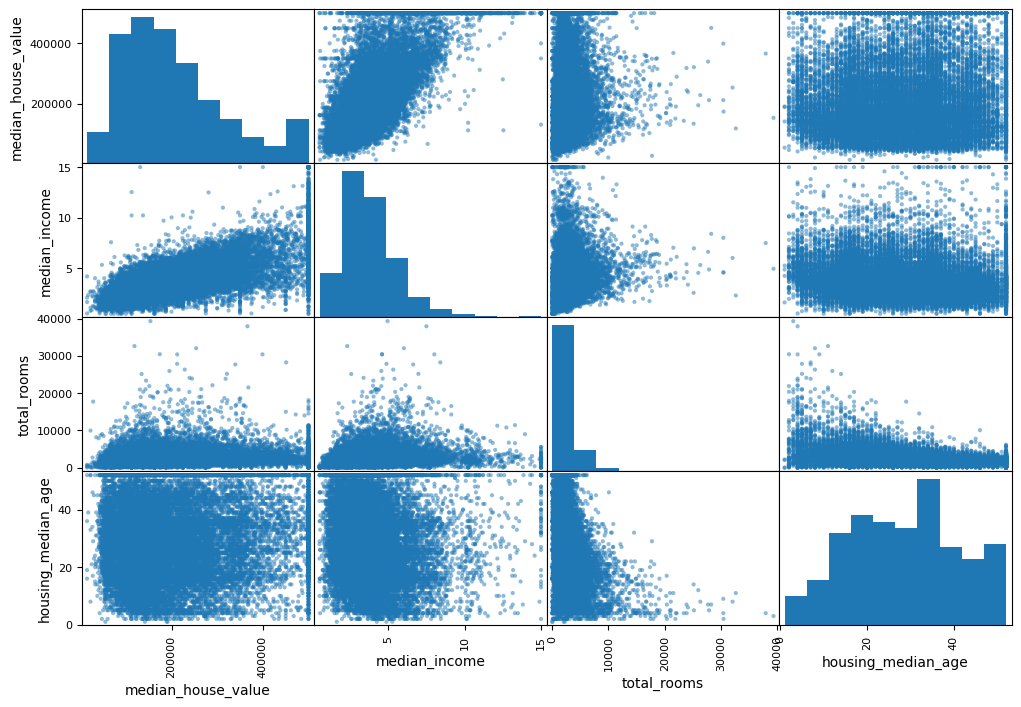

In [81]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))
plt.show()

In [82]:
# Select only numeric columns for correlation calculation
numeric_housing = housing.select_dtypes(include=[np.number])
corr_matrix = numeric_housing.corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

In [83]:
housing["rooms_per_household"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["population_per_household"] = housing["population"] / housing["households"]
print(housing["rooms_per_household"])
print(housing["bedrooms_per_room"])
print(housing["population_per_household"])

0        6.984127
1        6.238137
2        8.288136
3        5.817352
4        6.281853
           ...   
20635    5.045455
20636    6.114035
20637    5.205543
20638    5.329513
20639    5.254717
Name: rooms_per_household, Length: 20640, dtype: float64
0        0.146591
1        0.155797
2        0.129516
3        0.184458
4        0.172096
           ...   
20635    0.224625
20636    0.215208
20637    0.215173
20638    0.219892
20639    0.221185
Name: bedrooms_per_room, Length: 20640, dtype: float64
0        2.555556
1        2.109842
2        2.802260
3        2.547945
4        2.181467
           ...   
20635    2.560606
20636    3.122807
20637    2.325635
20638    2.123209
20639    2.616981
Name: population_per_household, Length: 20640, dtype: float64


In [84]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

"""housing.drop("total_bedrooms", axis=1, inplace=True)
housing.dropna(subset=["total_bedrooms"], inplace=True) 
median = housing["total_bedrooms"].median() 
housing["total_bedrooms"].fillna(median, inplace=True)"""

'housing.drop("total_bedrooms", axis=1, inplace=True)\nhousing.dropna(subset=["total_bedrooms"], inplace=True) \nmedian = housing["total_bedrooms"].median() \nhousing["total_bedrooms"].fillna(median, inplace=True)'

In [85]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
housing_num = housing.drop("ocean_proximity", axis=1)
imputer.fit(housing_num)
imputer.statistics_


array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [86]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(10)    

,ocean_proximity
12655,INLAND
15502,NEAR OCEAN
2908,INLAND
14053,NEAR OCEAN
20496,<1H OCEAN
1481,NEAR BAY
18125,<1H OCEAN
5830,<1H OCEAN
17989,<1H OCEAN
4861,<1H OCEAN


In [87]:
X = imputer.transform(housing_num)  
housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing.index)
print(housing_tr)

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
12655    -121.46     38.52                29.0       3873.0           797.0   
15502    -117.23     33.09                 7.0       5320.0           855.0   
2908     -119.04     35.37                44.0       1618.0           310.0   
14053    -117.13     32.75                24.0       1877.0           519.0   
20496    -118.70     34.28                27.0       3536.0           646.0   
...          ...       ...                 ...          ...             ...   
15174    -117.07     33.03                14.0       6665.0          1231.0   
12661    -121.42     38.51                15.0       7901.0          1422.0   
19263    -122.72     38.44                48.0        707.0           166.0   
19140    -122.70     38.31                14.0       3155.0           580.0   
19773    -122.14     39.97                27.0       1079.0           222.0   

       population  households  median_income  
1265

In [88]:
from sklearn.preprocessing import OrdinalEncoder    

ordinal_encoder = OrdinalEncoder()  

housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)
print(housing_cat_encoded)

[[1.]
 [4.]
 [1.]
 ...
 [0.]
 [0.]
 [1.]]


In [89]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [90]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()

housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
print(housing_cat_1hot.toarray())

[[0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0.]
 ...
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]]


In [91]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [92]:
from sklearn.base import BaseEstimator, TransformerMixin

rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6

class CombineAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room=True):
        self.add_bedrooms_per_room = add_bedrooms_per_room

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household = X[:, population_ix] / X[:, households_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]
        
attributes_adder = CombineAttributesAdder(add_bedrooms_per_room=False)
housing_extra_attribs = attributes_adder.transform(housing.to_numpy())
print(housing_extra_attribs)

[[-121.46 38.52 29.0 ... 'INLAND' 5.485835694050992 3.168555240793201]
 [-117.23 33.09 7.0 ... 'NEAR OCEAN' 6.927083333333333 2.6236979166666665]
 [-119.04 35.37 44.0 ... 'INLAND' 5.3933333333333335 2.223333333333333]
 ...
 [-122.72 38.44 48.0 ... '<1H OCEAN' 4.1104651162790695
  2.6627906976744184]
 [-122.7 38.31 14.0 ... '<1H OCEAN' 6.297405189620759 2.411177644710579]
 [-122.14 39.97 27.0 ... 'INLAND' 5.477157360406092 3.1725888324873095]]


In [93]:
def normalize(X):
    X_norm = np.copy(X)
    X_cols = X.shape[1]
    for i in range(X_cols):
        X_norm[:, i] = (X[:, i] - np.mean(X[:, i])) / np.std(X[:, i])
    return X_norm

In [94]:
def standarlize(X):
    X_std = np.copy(X)
    n_cols = X.shape[1]
    for i in range(n_cols):
        X_std[:, i] = (X[:, i] - np.mean(X[:, i])) / np.std(X[:, i])
    return X_std

In [95]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('attribs_adder', CombineAttributesAdder()),
    ('std_scaler', StandardScaler())
])
housing_num_tr  =num_pipeline.fit(housing_num)
print(housing_num_tr)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('attribs_adder', CombineAttributesAdder()),
                ('std_scaler', StandardScaler())])


In [96]:
from sklearn.compose import ColumnTransformer

num_attribs = list(housing_num)
cat_attribs = ["ocean_proximity"]

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs)
])

housing_prepared = full_pipeline.fit_transform(housing)

In [97]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

some_data = housing.iloc[:5]
some_labels = housing_labels.iloc[:5]
some_data_prepared = full_pipeline.transform(some_data)
print(lin_reg.predict(some_data_prepared))

[ 85657.90192014 305492.60737488 152056.46122456 186095.70946094
 244550.67966089]


In [98]:
print(list(some_labels))

[72100.0, 279600.0, 82700.0, 112500.0, 238300.0]


In [99]:
from sklearn.metrics import mean_absolute_error

housing_predicts = lin_reg.predict(housing_prepared)
lin_mse = mean_absolute_error(housing_labels, housing_predicts)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(222.34807984140096)

In [100]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor()
tree_reg.fit(housing_prepared, housing_labels)

housing_preditions = tree_reg.predict(housing_prepared)
tree_mse = mean_absolute_error(housing_labels, housing_preditions)
tree_rmse = np.sqrt(tree_mse)
tree_rmse


np.float64(0.0)

In [101]:
from  sklearn.model_selection import cross_val_score
scores = cross_val_score(tree_reg, housing_prepared, housing_labels, scoring="neg_mean_squared_error", cv=10)

tree_rmse_score = np.sqrt(-scores)
tree_rmse_score

array([72673.14242514, 69562.31101828, 69024.82227732, 70793.59031094,
       68933.50867035, 77801.87237112, 70923.91618247, 73959.23561781,
       69574.92633822, 70780.01197209])

In [102]:
def display_scores(scores):
    print(scores)
    print(scores.mean())
    print(scores.std())

display_scores(tree_rmse_score)

[72673.14242514 69562.31101828 69024.82227732 70793.59031094
 68933.50867035 77801.87237112 70923.91618247 73959.23561781
 69574.92633822 70780.01197209]
71402.73371837409
2618.5165787362284


In [103]:
lin_scores = cross_val_score(lin_reg, housing_prepared, housing_labels,
                             scoring="neg_mean_squared_error", cv=10)

lin_rmse_scores = np.sqrt(-lin_scores)
display_scores(lin_rmse_scores)


[71762.76364394 64114.99166359 67771.17124356 68635.19072082
 66846.14089488 72528.03725385 73997.08050233 68802.33629334
 66443.28836884 70139.79923956]
69104.07998247063
2880.328209818065


In [104]:
lin_scores = cross_val_score(lin_reg, housing_prepared, housing_labels,
                             scoring="neg_mean_squared_error", cv=10)

lin_rmse_scores = np.sqrt(-lin_scores)
display_scores(lin_rmse_scores)


[71762.76364394 64114.99166359 67771.17124356 68635.19072082
 66846.14089488 72528.03725385 73997.08050233 68802.33629334
 66443.28836884 70139.79923956]
69104.07998247063
2880.328209818065


In [105]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(tree_reg, housing_prepared, housing_labels,
                         scoring="neg_mean_squared_error", cv=10)

tree_rmse_scores = np.sqrt(-scores)


In [106]:
from sklearn.ensemble import RandomForestRegressor

def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

display_scores(tree_rmse_scores)

Scores: [73027.98132785 69867.27909527 68852.9401538  72063.26341673
 70580.57221357 78117.75767478 70552.82490906 74252.70292796
 68142.05532364 71897.98506387]
Mean: 71735.53621065253
Standard deviation: 2762.5836756797107


In [60]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

tree_reg = DecisionTreeRegressor()
tree_reg.fit(housing_prepared, housing_labels)

housing_predictions = tree_reg.predict(housing_prepared)
tree_mse = mean_squared_error(housing_labels, housing_predictions)
tree_rmse = np.sqrt(tree_mse)
tree_rmse


np.float64(0.0)

In [107]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

forest_reg = RandomForestRegressor()
forest_reg.fit(housing_prepared, housing_labels)

forest_mse = mean_squared_error(housing_labels, housing_predictions)
forest_rmse = np.sqrt(forest_mse)
forest_rmse

np.float64(0.0)

In [108]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
]

forest_reg = RandomForestRegressor()

grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)

grid_search.fit(housing_prepared, housing_labels)
grid_search.best_estimator_

RandomForestRegressor(max_features=6, n_estimators=30)

In [ ]:

from sklearn.ensemble import RandomForestRegressor

RandomForestRegressor(bootstrap=True, criterion='mse', max_depth=None,
                      max_features=8, max_leaf_nodes=None, min_impurity_decrease=0.0,
                      min_impurity_split=None, min_samples_leaf=1,
                      min_samples_split=2, min_weight_fraction_leaf=0.0,
                      n_estimators=30, n_jobs=None, oob_score=False, random_state=None,
                      verbose=0, warm_start=False)


TypeError: RandomForestRegressor.__init__() got an unexpected keyword argument 'min_impurity_split'

In [ ]:
cvres = grid_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)


63283.238214744495 {'max_features': 2, 'n_estimators': 3}
55428.43739098771 {'max_features': 2, 'n_estimators': 10}
52660.63297608943 {'max_features': 2, 'n_estimators': 30}
59960.882412084495 {'max_features': 4, 'n_estimators': 3}
52401.62879096881 {'max_features': 4, 'n_estimators': 10}
50691.824101138955 {'max_features': 4, 'n_estimators': 30}
58401.995144172746 {'max_features': 6, 'n_estimators': 3}
52143.60725073869 {'max_features': 6, 'n_estimators': 10}
49631.19151017093 {'max_features': 6, 'n_estimators': 30}
58561.474751698144 {'max_features': 8, 'n_estimators': 3}
52096.70797879934 {'max_features': 8, 'n_estimators': 10}
50136.83768148086 {'max_features': 8, 'n_estimators': 30}
62165.295823501365 {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
53935.693220242356 {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
59800.492958205505 {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
52659.35949166122 {'bootstrap': False, 'max_features': 3, 'n_estimat